In [ ]:
# Install Ultralytics framework
!pip install ultralytics -q

# Install Roboflow for seamless dataset downloading
!pip install roboflow -q

# Clear output and verify installation
import os
import ultralytics
from ultralytics import YOLO

ultralytics.checks()

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.1/112.6 GB disk)


In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="nmmrbjRIkKkRTCm7qfCQ")
project = rf.workspace("bere-gcgue").project("smartphones_capstone")
dataset = project.version(1).download("yolov11")

# Define path to the data.yaml file generated by Roboflow
dataset_yaml_path = os.path.join(dataset.location, "data.yaml")
print(f"Dataset downloaded successfully at: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov11 in progress : 26.0%
Version export complete for yolov11 format



Extracting Dataset Version Zip to smartphones_capstone-1 in yolov11:: 100%|██████████| 455/455 [00:00<00:00, 10396.82it/s]

Dataset downloaded successfully at: /content/smartphones_capstone-1


In [ ]:
# 1. Load the pre-trained YOLOv11 Nano weights to leverage Transfer Learning
model = YOLO("yolo11n.pt")

# 2. Begin training with optimized hyperparameters
results = model.train(
    data=dataset_yaml_path,     # Path to your data.yaml file
    epochs=120,                 # Recommended number of epochs for convergence
    imgsz=1024,                 # Increased from 640 to 1024 to capture minute generational differences (bezel/camera buttons)
    batch=16,                   # Adjust to 8 if you run out of GPU memory (VRAM)
    lr0=0.005,                  # Slightly lowered initial learning rate for more stable weight fine-tuning
    patience=30,                # Early stopping: halts training if validation loss doesn't improve for 30 epochs
    device=0,                   # Uses the Google Colab T4 GPU
    workers=2,                  # Number of CPU workers for data loading
    plots=True                  # Generates confusion matrices and training charts automatically
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/smartphones_capstone-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, p

In [ ]:
# Evaluate model performance on the validation set
metrics = model.val()

print("\n=== FINAL TRAINING METRICS ===")
print(f"mAP50:     {metrics.box.map50 * 100:.2f}%")
print(f"mAP50-95:  {metrics.box.map:.2f}%")
print(f"Precision: {metrics.box.mp * 100:.2f}%")
print(f"Recall:    {metrics.box.mr * 100:.2f}%")
print(f"F1-Score:  {metrics.box.f1.mean() * 100:.2f}%")

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,584,102 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 903.5±375.6 MB/s, size: 19.1 KB)
val: Scanning /content/smartphones_capstone-1/valid/labels.cache... 41 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 41/41 14.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.5s/it 4.4s
                   all         41         41      0.663      0.841      0.847      0.729
  asus_rog_phone_9_pro          3          3      0.509          1      0.913      0.855
            iphone_16e          8          8      0.861      0.779      0.902      0.796
     iphone_17_pro_max          3          3      0.697       0.79       0.83      0.548
nothing_cmf_phone_2_pro          4          4      0.934          1      0.995      0.932
            oneplus_13          5   


image 1/1 /content/smartphones_capstone-1/test/images/Screenshot-2026-05-16-000423_png.rf.9c5a087699969fbd27637a8781cbf734.jpg: 1024x1024 (no detections), 14.2ms
Speed: 27.9ms preprocess, 14.2ms inference, 0.7ms postprocess per image at shape (1, 3, 1024, 1024)


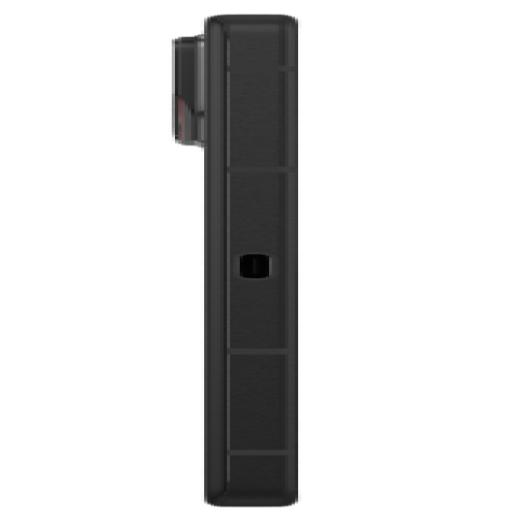

In [ ]:
import cv2

# Colab-safe display helper: use cv2_imshow on Colab, fallback to matplotlib locally
try:
    from google.colab.patches import cv2_imshow as _show_image
except ModuleNotFoundError:
    import matplotlib.pyplot as plt
    
    def _show_image(img_bgr):
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 6))
        plt.imshow(img_rgb)
        plt.axis("off")
        plt.show()

# Select an unseen image from your test dataset directory
test_images_dir = os.path.join(dataset.location, "test", "images")
sample_image = os.path.join(test_images_dir, os.listdir(test_images_dir)[0])

# Run inference
prediction_results = model(sample_image)

# Loop through predictions and print the JSON metadata required by your FastAPI/SQL backend
for result in prediction_results:
    # Render and display the visual bounding box preview
    annotated_img = result.plot()
    _show_image(annotated_img)

    # Print the clean JSON properties needed for Arda's SQL schema hook
    for box in result.boxes:
        class_id = int(box.cls[0])
        model_name = result.names[class_id]
        confidence = float(box.conf[0])

        print("\n--- Model Layer JSON Target Data ---")
        print({
            "detected_object": "smartphone",
            "model_id": model_name,
            "confidence_score": round(confidence, 3),
            "action": "trigger_db_lookup"
        })

In [ ]:
# Export to standard serialized PyTorch format (.pt) or optimized OpenVINO/ONNX runtime format
model.export(format="onnx")

print("Training pipeline finished. Download your weights from the 'runs/detect/train/weights/' folder in the file browser sidebar.")

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 1024, 1024) BCHW and output shape(s) (1, 14, 21504) (5.3 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 262ms
Prepared 4 packages in 5.92s
Installed 4 packages in 271ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.26.0
 + onnxslim==0.1.93

requirements: AutoUpdate success ✅ 7.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.93...
ONNX: export success ✅ 11.1s, saved as '/content/